In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv('data/college_sleep_and_gpa.csv')

In [46]:
df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


In [47]:
df.dtypes

student_id                   int64
study                        int64
university                  object
semester                    object
cohort_code                 object
gender                      object
first_generation           float64
underrepresented           float64
avg_sleep_minutes          float64
avg_sleep_hours            float64
daytime_sleep_minutes      float64
sleep_midpoint_minutes     float64
bedtime_variability        float64
nights_tracked_fraction    float64
prior_gpa                  float64
term_gpa                   float64
gpa_change                 float64
term_units                 float64
term_load_z                float64
under_6h_sleep               int64
sleep_bracket               object
sleep_midpoint_clock        object
dtype: object

In [48]:
df.isnull().sum()

student_id                   0
study                        0
university                   0
semester                     0
cohort_code                  0
gender                       3
first_generation             4
underrepresented             1
avg_sleep_minutes            0
avg_sleep_hours              0
daytime_sleep_minutes        0
sleep_midpoint_minutes       0
bedtime_variability          0
nights_tracked_fraction      0
prior_gpa                    0
term_gpa                     0
gpa_change                   0
term_units                 147
term_load_z                147
under_6h_sleep               0
sleep_bracket                0
sleep_midpoint_clock         0
dtype: int64

In [49]:
df.columns

Index(['student_id', 'study', 'university', 'semester', 'cohort_code',
       'gender', 'first_generation', 'underrepresented', 'avg_sleep_minutes',
       'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes',
       'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa',
       'term_gpa', 'gpa_change', 'term_units', 'term_load_z', 'under_6h_sleep',
       'sleep_bracket', 'sleep_midpoint_clock'],
      dtype='object')

In [50]:
clean_df = df[['student_id', 'university', 'gender', 'first_generation', 'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes', 'prior_gpa', 'term_gpa', 'gpa_change', 'term_units']]

In [51]:
clean_df.columns

Index(['student_id', 'university', 'gender', 'first_generation',
       'avg_sleep_minutes', 'avg_sleep_hours', 'daytime_sleep_minutes',
       'prior_gpa', 'term_gpa', 'gpa_change', 'term_units'],
      dtype='object')

Is there a postiive or negative correlation from the amount of sleep a student gets (avg_sleep_minutes) and the gpa (term_gpa) that they finish the term with. 

In [52]:
clean_df.isnull().sum()

student_id                 0
university                 0
gender                     3
first_generation           4
avg_sleep_minutes          0
avg_sleep_hours            0
daytime_sleep_minutes      0
prior_gpa                  0
term_gpa                   0
gpa_change                 0
term_units               147
dtype: int64

In [53]:
df.shape

(634, 22)

In [54]:
df['avg_sleep_hours'].describe()

count    634.000000
mean       6.622098
std        0.847741
min        3.250000
25%        6.112500
50%        6.675000
75%        7.170000
max        9.790000
Name: avg_sleep_hours, dtype: float64

In [55]:
# making a loop to categorize the hours into bins

def loopy(hours):
    if 3 <= hours <= 5:
        return 'bad'
    elif 5 <= hours <= 7:
        return 'good'
    else:
        return 'great'



In [56]:
# making a new column from the loop

df['sleep'] = df['avg_sleep_hours'].apply(loopy).copy()

In [57]:
df.head()

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock,sleep
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20,good
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00,good
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38,bad
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52,good
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54,good


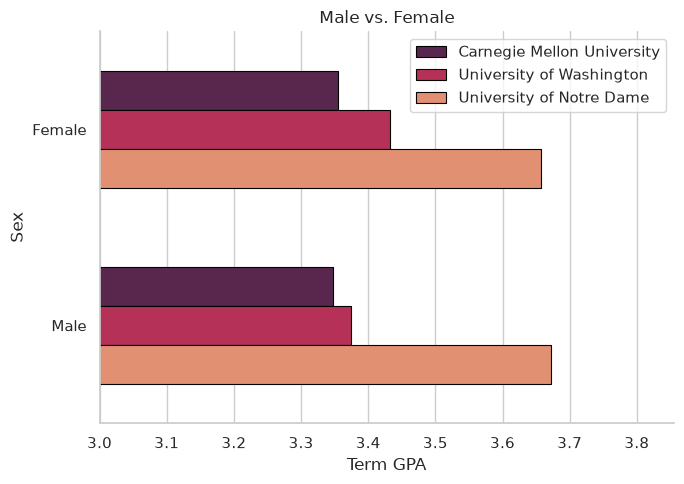

In [58]:

# 1. Set a clean theme
sns.set_theme(style="whitegrid", font_scale=1)

# 2. Create the figure with good proportions
plt.figure(figsize = (7, 5))

# 3. Plot with a nice palette
sns.barplot(
    data=df,
    x='term_gpa',
    y='gender',
    hue='university',    
    errorbar = None,   
    palette='rocket',      
    edgecolor='black',
    linewidth=0.8,
    width=0.6
)

plt.xlim(3.0, )
plt.legend(loc = 'upper right')
plt.title('Male vs. Female')
plt.ylabel('Sex')
plt.xlabel('Term GPA')

sns.despine(top=True, right=True)



plt.tight_layout()
plt.show()